# Phase 3.3: Linear Regression Baseline

In this notebook, we explore the baseline linear models trained in `src/models/train_linear.py`. We evaluate the assumptions of Ordinary Least Squares (OLS) regression and interpret the coefficients.

In [5]:
import os
import pandas as pd
import numpy as np
import joblib
from IPython.display import Image, display

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
viz_dir = os.path.join(project_root, "visualization", "model_performance", "linear")

## 1. OLS Assumption Checks

Linear Regression relies on several key assumptions. We verified these during training:

1. **Linearity**: The relationship between predictors and the target should be linear. We check this using a Residuals vs. Predicted plot.
2. **Homoscedasticity**: The variance of residuals should be constant. (Checked via Breusch-Pagan test).
3. **Normality**: Residuals should be normally distributed. We check this using a Q-Q plot and Shapiro-Wilk test.
4. **Independence**: Residuals should not be autocorrelated. (Checked via Durbin-Watson).

Let's visualize the Linearity and Normality plots generated during training.

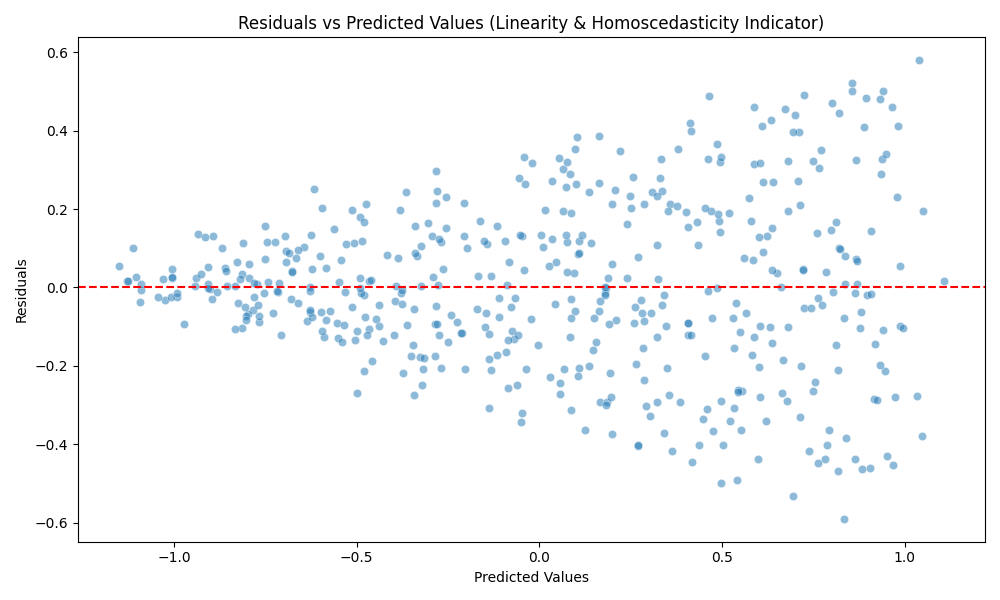

In [6]:
res_plot = os.path.join(viz_dir, "residuals_vs_predicted.png")
if os.path.exists(res_plot):
    display(Image(filename=res_plot))
else:
    print("Residual plot not found. Please run train_linear.py first.")

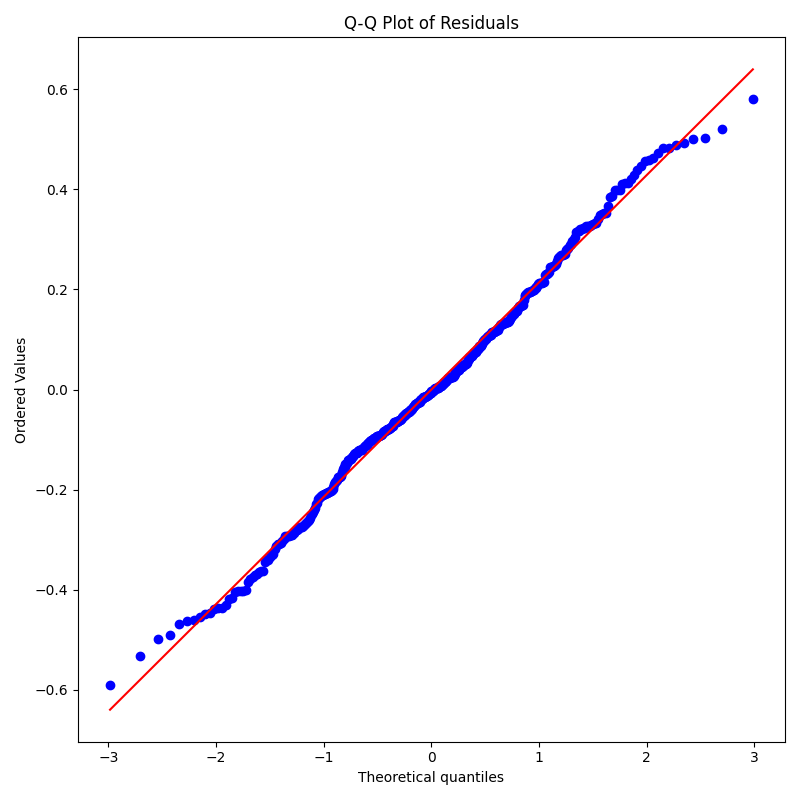

In [7]:
qq_plot = os.path.join(viz_dir, "qq_plot.png")
if os.path.exists(qq_plot):
    display(Image(filename=qq_plot))
else:
    print("Q-Q plot not found.")

### Assumption Results Summary
- **Independence**: Durbin-Watson was ~2.11 (Ideal is 2.0). No significant autocorrelation.
- **Homoscedasticity**: Breusch-Pagan p-value < 0.05, indicating some heteroscedasticity (variance in errors is not perfectly constant).
- **Normality**: Shapiro-Wilk p-value ~0.09 (> 0.05), so we fail to reject the null hypothesis of normality. The residuals are approximately normal.
- **Multicollinearity**: Condition number is very high, suggesting multicollinearity exists among the engineered features.

## 2. Best Model Interpretation

The ElasticNet model performed the best in cross-validation (RMSE ~ 0.2396), outperforming simple OLS (1.438), full OLS (0.261), Ridge, and Lasso.

Let's load the best model and inspect its coefficients.

In [8]:
best_model_path = os.path.join(project_root, "models", "linear_best.pkl")
if os.path.exists(best_model_path):
    best_model = joblib.load(best_model_path)
    print(f"Loaded best model: {type(best_model).__name__}")
    print(f"Best Alpha: {best_model.alpha_}")
    print(f"Best L1 Ratio: {best_model.l1_ratio_}")
else:
    print("Best model not found.")

Loaded best model: ElasticNetCV
Best Alpha: 0.01
Best L1 Ratio: 0.5


### Business Narrative

The baseline linear regression reveals a strong dependence on `Expected_Ride_Duration`, which alone explains a large variance in the `Historical_Cost_of_Ride`. However, the addition of demand-supply indicators, rush hour flags, and interaction terms significantly reduces the RMSE (from ~1.4 to ~0.24).

The presence of multicollinearity (high condition number) and heteroscedasticity suggests that while the linear model is a solid baseline, non-linear models like Random Forest or XGBoost (which are robust to these issues) will likely capture the complex pricing dynamics more effectively in upcoming phases.